## Code for plotting Site U1554 XRF data 

In [1]:
import pandas, numpy, scipy, matplotlib, seaborn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import scipy.signal as signal
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

In [2]:
###  Import Site U1554 Bjorn Drift XRF data ###
# Hole E
E_10kV = pd.read_csv('data/U1554/hole_E/395C_U1554E_10kV_0_16mA_No-Filter_6s_DC10mm_CC12mm_Clean.csv')
E_30kV = pd.read_csv('data/U1554/hole_E/395C_U1554E_30kV_1_25mA_Pd-Thick_6s_DC10mm_CC12mm_Clean.csv')
E_50kV = pd.read_csv('data/U1554/hole_E/395C_U1554E_50kV_0_75mA_Cu_10s_DC10mm_CC12mm_Clean.csv')

# Splice
splice_10kV = pd.read_csv('data/U1554/splice/395-U1554_10kV_0_16mA_No-Filter_6s_DC10mm_CC12mm_Clean.csv')
splice_30kV = pd.read_csv('data/U1554/splice/395-U1554_30kV_1_25mA_Pd-Thick_6s_DC10mm_CC12mm_Clean.csv')
splice_50kV = pd.read_csv('data/U1554/splice/395-U1554_50kV_0_75mA_Cu_10s_DC10mm_CC12mm_Clean.csv')

## U1554 Hole E physical properties ##
U1554E_ms = pd.read_csv('data/U1554/U1554E_MS_clean.csv')
U1554E_ngr = pd.read_csv('data/U1554/U1554E_NGR_Clean.csv')

## U1554 SPLICE physical properties ##

## U1554 age model and lith units ##
U1554agemodel = pd.read_csv('data/U1554/age_model/U1554-agemodel-csf-ccsf.csv')
U1554lithunits=pd.read_csv('data/U1554/age_model/U1554-lithunits-csf-ccsf.csv')

In [3]:
GSA_EPOCH_COLORS = {
    'Pleistocene': '#FEEFBC',
    'Pliocene':    '#FFF8AE',
    'Miocene':     '#FFF101',
    'Oligocene':   '#FEDAAB',
    'Eocene':      '#FBBB85',
}

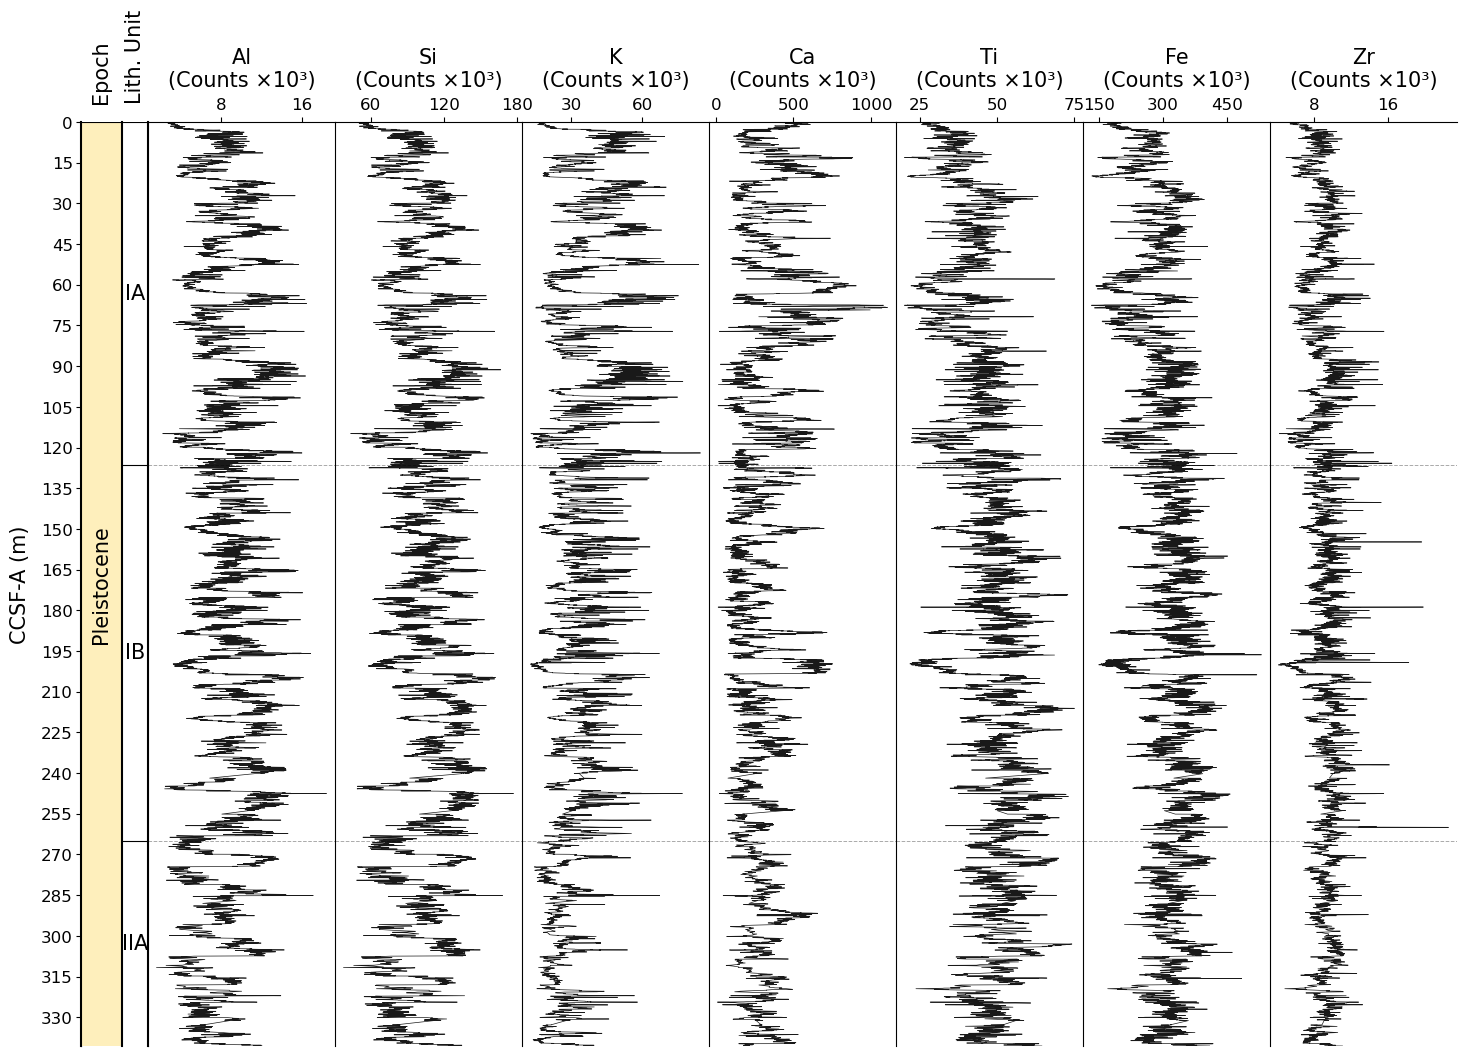

In [4]:
depth = 'CCSF-395-U1554-ABCEGH-20230705-for_EGHv2 (m)'

colors = {
    'Al': 'black', 'Si': 'black', 'K':  'black', 'Ca': 'black',
    'Ti': 'black', 'Fe': 'black', 'Zr': 'black',
}
elements = {
    'Al': (splice_10kV, 'Al-Ka Area'),
    'Si': (splice_10kV, 'Si-Ka Area'),
    'K':  (splice_10kV, 'K -Ka Area'),
    'Ca': (splice_10kV, 'Ca-Ka Area'),
    'Ti': (splice_10kV, 'Ti-Ka Area'),
    'Fe': (splice_10kV, 'Fe-Ka Area'),
    'Zr': (splice_30kV, 'Zr-Ka Area'),
}

# ── boundaries using CCSF-A depths ───────────────────────────────────────────
lith_boundaries  = [0.0] + list(U1554lithunits['Depth CCSF-A (m)'])
lith_labels      = ['']  + list(U1554lithunits['Lithostrat Unit'])

epoch_boundaries = [0.0] + list(U1554agemodel['Depth CCSF-A (m)'])
epoch_labels     = ['']  + list(U1554agemodel['Event (base)'])

boundaries = list(U1554lithunits['Depth CCSF-A (m)'])  # dashed lines on data panels

y_min = 0
y_max = max(splice_10kV[depth].max(), splice_30kV[depth].max())

n_cols = 1 + 1 + 1 + len(elements)   # depth | epoch | lith | elements

fig = plt.figure(figsize=(4 + 2*len(elements), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.10, 0.22, 0.14] + [1]*len(elements),
                        wspace=0.0)

# ── depth axis ────────────────────────────────────────────────────────────────
ax_depth = fig.add_subplot(gs[0])
ax_depth.set_ylim(y_max, y_min)
ax_depth.set_xlim(0, 1)
ax_depth.set_xticks([])
ax_depth.yaxis.set_major_locator(plt.MaxNLocator(25))
ax_depth.tick_params(axis='y', labelsize=12, left=True, labelleft=True,
                     right=False, pad=2)
ax_depth.set_ylabel('CCSF-A (m)', fontsize=15, labelpad=8)
for spine in ax_depth.spines.values():
    spine.set_visible(False)
ax_depth.spines['left'].set_visible(True)

# ── reusable boundary drawing function ───────────────────────────────────────
def draw_boundaries(ax, depths, labels, fontsize=9, rotation=0,
                    left_line=True, right_line=True, epoch_colors=None,
                    y_max=None):
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    trans_data = blended_transform_factory(ax.transAxes, ax.transData)
    trans_axes = ax.transAxes

    if epoch_colors:
        for i in range(1, len(depths)):
            color = epoch_colors.get(labels[i], 'white')
            ax.axhspan(depths[i-1], depths[i], facecolor=color, alpha=1.0, zorder=1)

    for d in depths:
        ax.axhline(d, color='black', linewidth=0.8, zorder=3)

    if left_line:
        ax.plot([0, 0], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)
    if right_line:
        ax.plot([1, 1], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)

    for i in range(1, len(depths)):
        top    = depths[i-1]
        bottom = depths[i]
        # cap bottom at y_max so the label stays visible for the last interval
        if y_max is not None:
            bottom = min(bottom, y_max)
        mid = (top + bottom) / 2
        ax.text(0.5, mid, labels[i],
                ha='center', va='center',
                fontsize=fontsize, fontweight='400', color='black',
                rotation=rotation,
                transform=trans_data, zorder=4, clip_on=True)

# ── epoch axis ────────────────────────────────────────────────────────────────
ax_age = fig.add_subplot(gs[1], sharey=ax_depth)
draw_boundaries(ax_age, epoch_boundaries, epoch_labels,
                fontsize=15, rotation=90,
                left_line=True, right_line=False,
                epoch_colors=GSA_EPOCH_COLORS, y_max=y_max)

ax_age.text(0.5, 1.02, 'Epoch', fontsize=15,
            ha='center', va='bottom', rotation=90,
            transform=ax_age.transAxes)

# ── lith axis ─────────────────────────────────────────────────────────────────
ax_lith = fig.add_subplot(gs[2], sharey=ax_depth)
draw_boundaries(ax_lith, lith_boundaries, lith_labels,
                fontsize=15, rotation=0,
                left_line=True, right_line=True, y_max=y_max)

ax_lith.text(0.5, 1.02, 'Lith. Unit', fontsize=15,
             ha='center', va='bottom', rotation=90,
             transform=ax_lith.transAxes)

# ── element panels ────────────────────────────────────────────────────────────
all_axes = [fig.add_subplot(gs[i+3], sharey=ax_depth) for i in range(len(elements))]

for i, (ax, (element, (df, col))) in enumerate(zip(all_axes, elements.items())):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(df[col], df[depth], color=colors[element], linewidth=0.5, alpha=0.9)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(f'{element}\n(Counts ×10³)', fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

# ── flush to depth spine ──────────────────────────────────────────────────────
fig.canvas.draw()
spine_x    = ax_depth.spines['left'].get_window_extent().x1
lith_left  = fig.transFigure.inverted().transform((spine_x, 0))[0]
shift      = ax_age.get_position().x0 - lith_left

for ax in [ax_age, ax_lith] + all_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

plt.show()

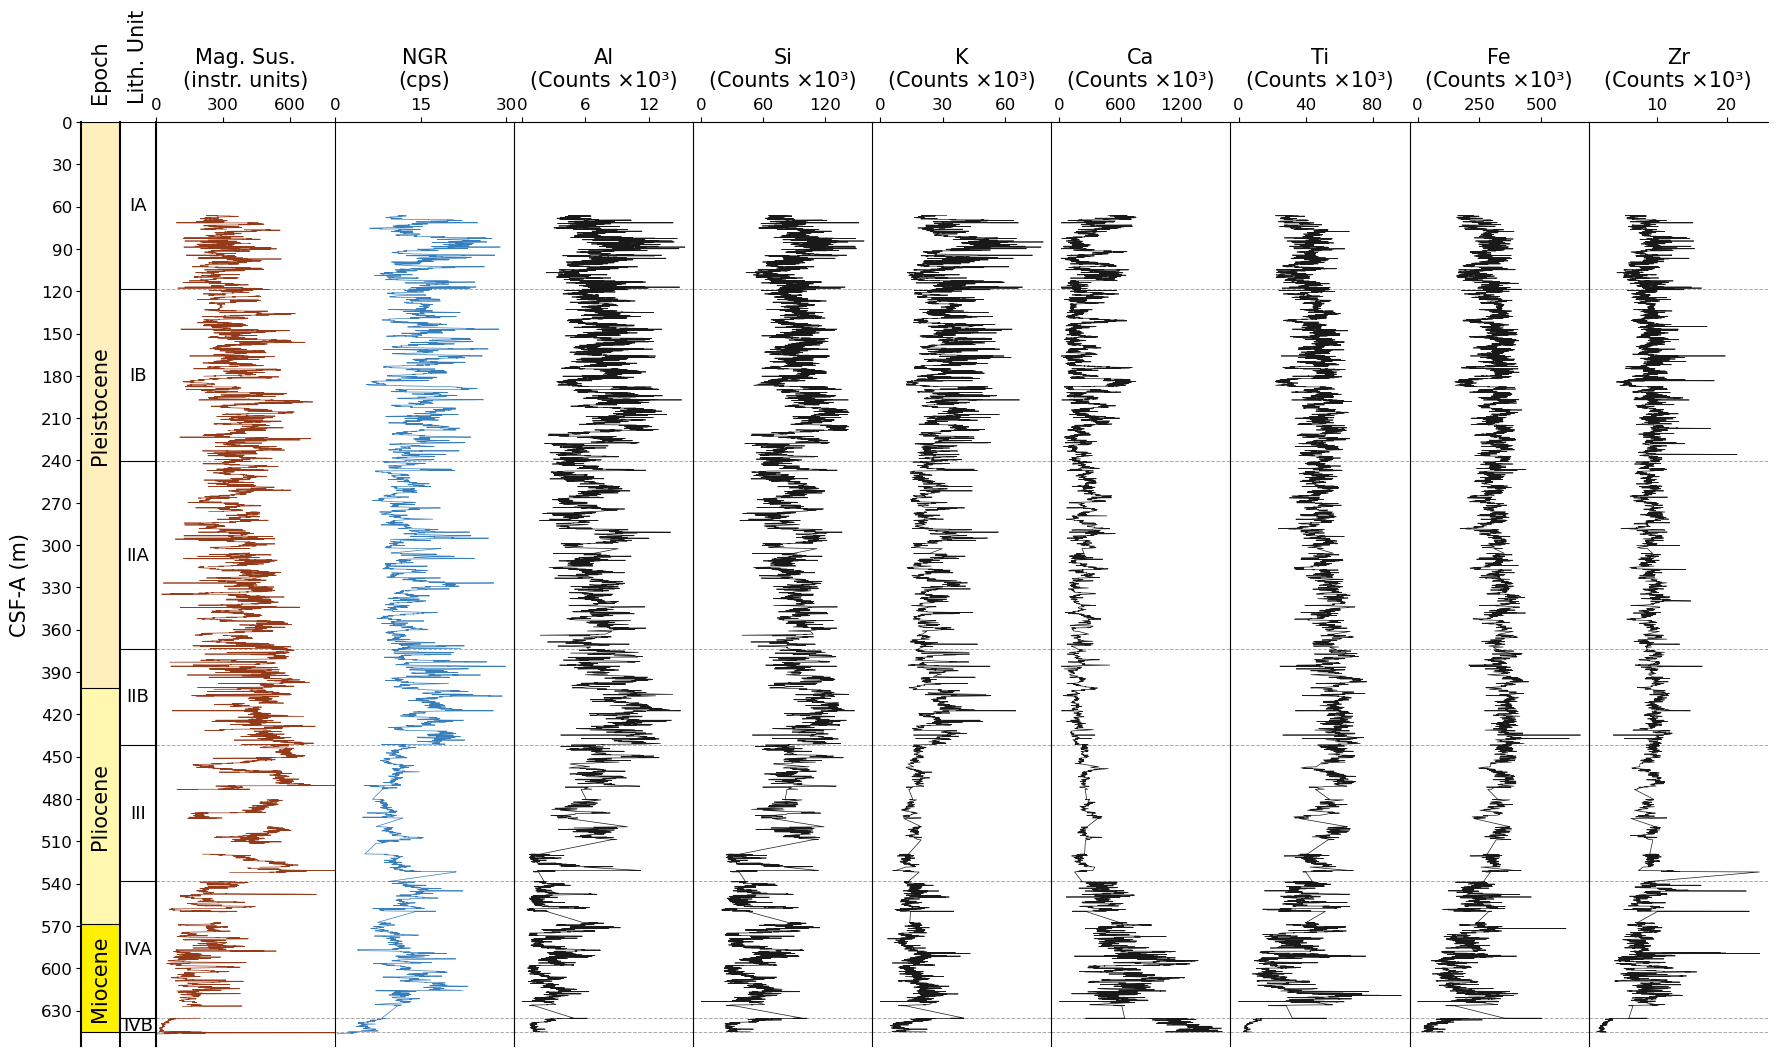

In [5]:
depth_E = 'CSF-A (m)'

# ── element definitions ───────────────────────────────────────────────────────
elements_E = {
    'Al': (E_10kV, 'Al-Ka Area'),
    'Si': (E_10kV, 'Si-Ka Area'),
    'K':  (E_10kV, 'K -Ka Area'),
    'Ca': (E_10kV, 'Ca-Ka Area'),
    'Ti': (E_10kV, 'Ti-Ka Area'),
    'Fe': (E_10kV, 'Fe-Ka Area'),
    'Zr': (E_30kV, 'Zr-Ka Area'),
}

# ── boundaries straight from the dataframes ───────────────────────────────────
lith_boundaries  = [0.0] + list(U1554lithunits['Depth CSF-A (m)'])
lith_labels      = ['']  + list(U1554lithunits['Lithostrat Unit'])

epoch_boundaries = [0.0] + list(U1554agemodel['Depth CSF-A (m)'])
epoch_labels     = ['']  + list(U1554agemodel['Event (base)'])

boundaries = list(U1554lithunits['Depth CSF-A (m)'])

y_min_E = 0
y_max_E = max(E_10kV[depth_E].max(), E_30kV[depth_E].max())

# ── extra panels ──────────────────────────────────────────────────────────────
extra_panels = [
    {
        'df':    U1554E_ms,
        'xcol':  'MagneticSusceptibilityinstrUnits',
        'ycol':  'DepthCSFAm',
        'label': 'Mag. Sus.\n(instr. units)',
        'color': '#8B2500',
        'xlim':  (0, 800),
    },
    {
        'df':    U1554E_ngr,
        'xcol':  'NGR total counts (cps)',
        'ycol':  'Depth CSF-A (m)',
        'label': 'NGR\n(cps)',
        'color': '#2171B5',
        'xlim':  (0, None),
    },
]

n_extra = len(extra_panels)
n_xrf   = len(elements_E)
n_cols  = 2 + 1 + n_extra + n_xrf   # depth | epoch | lith | MS | NGR | XRF...

fig = plt.figure(figsize=(4 + 2*(n_extra + n_xrf), 12))
gs  = gridspec.GridSpec(1, n_cols,
                        width_ratios=[0.1, 0.22, 0.2] + [1]*(n_extra + n_xrf),
                        wspace=0.0)

# ── depth axis ────────────────────────────────────────────────────────────────
ax_depth = fig.add_subplot(gs[0])
ax_depth.set_ylim(y_max_E+10, y_min_E)
ax_depth.set_xlim(0, 1)
ax_depth.set_xticks([])
ax_depth.yaxis.set_major_locator(plt.MaxNLocator(25))
ax_depth.tick_params(axis='y', labelsize=12, left=True, labelleft=True,
                     right=False, pad=2)
ax_depth.set_ylabel('CSF-A (m)', fontsize=15, labelpad=8)
for spine in ax_depth.spines.values():
    spine.set_visible(False)
ax_depth.spines['left'].set_visible(True)

# ── boundary drawing helper ───────────────────────────────────────────────────
def draw_boundaries(ax, depths, labels, fontsize=9, rotation=0,
                    left_line=True, right_line=True, epoch_colors=None,
                    y_max=None):
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    trans_data = blended_transform_factory(ax.transAxes, ax.transData)
    trans_axes = ax.transAxes

    if epoch_colors:
        for i in range(1, len(depths)):
            color = epoch_colors.get(labels[i], 'white')
            ax.axhspan(depths[i-1], depths[i], facecolor=color, alpha=1.0, zorder=1)

    for d in depths:
        ax.axhline(d, color='black', linewidth=0.8, zorder=3)

    if left_line:
        ax.plot([0, 0], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)
    if right_line:
        ax.plot([1, 1], [0, 1], color='black', linewidth=1.5,
                transform=trans_axes, zorder=5, clip_on=False)

    for i in range(1, len(depths)):
        top    = depths[i-1]
        bottom = depths[i]
        if y_max is not None:
            bottom = min(bottom, y_max)
        mid    = (top + bottom) / 2
        ax.text(0.5, mid, labels[i],
                ha='center', va='center',
                fontsize=fontsize, fontweight='400', color='black',
                rotation=rotation,
                transform=trans_data, zorder=4, clip_on=True)

# ── epoch axis ────────────────────────────────────────────────────────────────
ax_age = fig.add_subplot(gs[1], sharey=ax_depth)
draw_boundaries(ax_age, epoch_boundaries, epoch_labels,
                fontsize=15, rotation=90,
                left_line=True, right_line=False,
                epoch_colors=GSA_EPOCH_COLORS, y_max=y_max_E)
ax_age.text(0.5, 1.02, 'Epoch', fontsize=15,
            ha='center', va='bottom', rotation=90,
            transform=ax_age.transAxes)

# ── lith axis ─────────────────────────────────────────────────────────────────
ax_lith = fig.add_subplot(gs[2], sharey=ax_depth)
draw_boundaries(ax_lith, lith_boundaries, lith_labels,
                fontsize=13, rotation=0,
                left_line=True, right_line=True, y_max=y_max_E)
ax_lith.text(0.5, 1.02, 'Lith. Unit', fontsize=15,
             ha='center', va='bottom', rotation=90,
             transform=ax_lith.transAxes)

# ── data panels ───────────────────────────────────────────────────────────────
all_axes = [fig.add_subplot(gs[i + 3], sharey=ax_depth)
            for i in range(n_extra + n_xrf)]

for i, (ax, panel) in enumerate(zip(all_axes[:n_extra], extra_panels)):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(panel['df'][panel['xcol']], panel['df'][panel['ycol']],
            color=panel['color'], linewidth=0.5, alpha=0.9)

    lo, hi = panel['xlim']
    if lo is not None or hi is not None:
        cur_lo, cur_hi = ax.get_xlim()
        ax.set_xlim(lo if lo is not None else cur_lo,
                    hi if hi is not None else cur_hi)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(panel['label'], fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.spines['left'].set_visible(True)

for ax, (element, (df, col)) in zip(all_axes[n_extra:], elements_E.items()):
    for b in boundaries:
        ax.axhline(b, color='#aaaaaa', linewidth=0.7, linestyle='--', zorder=1)

    ax.plot(df[col], df[depth_E], color='black', linewidth=0.5, alpha=0.9)

    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.set_xlabel(f'{element}\n(Counts ×10³)', fontsize=15, labelpad=8)
    ax.tick_params(axis='x', labelsize=12, top=True, labeltop=True,
                   bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelleft=False, left=False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── flush to depth spine ──────────────────────────────────────────────────────
fig.canvas.draw()
spine_x   = ax_depth.spines['left'].get_window_extent().x1
lith_left = fig.transFigure.inverted().transform((spine_x, 0))[0]
shift     = ax_age.get_position().x0 - lith_left

for ax in [ax_age, ax_lith] + all_axes:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift, pos.y0, pos.width, pos.height])

plt.show()

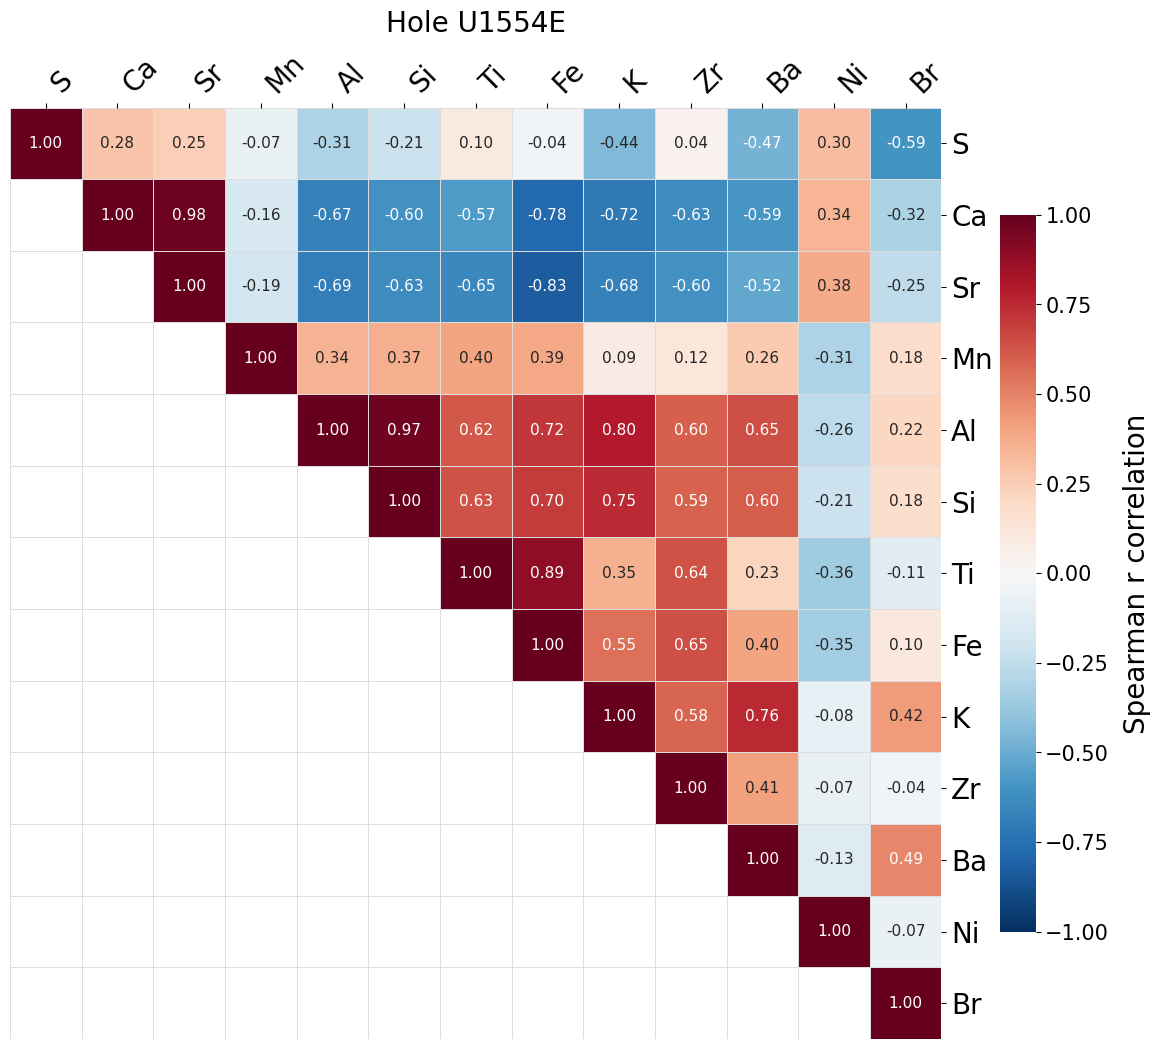

In [6]:
# S, Ca, Al, Si, Ti, Fe, K, Mn from 10kV
# Zr, Sr, Ni, Br from 30kV
# Ba from 50kV

elements_corr = {
    'S':  E_10kV['S -Ka Area'],
    'Ca': E_10kV['Ca-Ka Area'],
    'Sr': E_30kV['Sr-Ka Area'],
    'Mn': E_10kV['Mn-Ka Area'],
    'Al': E_10kV['Al-Ka Area'],
    'Si': E_10kV['Si-Ka Area'],
    'Ti': E_10kV['Ti-Ka Area'],
    'Fe': E_10kV['Fe-Ka Area'],
    'K':  E_10kV['K -Ka Area'],
    'Zr': E_30kV['Zr-Ka Area'],
    'Ba': E_50kV['Ba-Ka Area'],
    'Ni': E_30kV['Ni-Ka Area'],
    'Br': E_30kV['Br-Ka Area'],
}

# align lengths since they come from different voltage files
df_corr = pd.DataFrame({k: v.values for k, v in elements_corr.items()})

# compute spearman correlation matrix
corr_matrix = df_corr.corr(method='spearman')

# plot
fig, ax = plt.subplots(figsize=(12, 11))

mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='#dddddd',
            annot_kws={'size': 11},
            cbar_kws={'shrink': 0.7},
            ax=ax)

ax.set_title('Hole U1554E', fontsize=20, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left', fontsize=20)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=20)
ax.xaxis.tick_top()
ax.yaxis.tick_right()

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Spearman r correlation', fontsize=20, labelpad=10)

plt.tight_layout()
plt.show()

In [7]:
## prep for the correlation plots

def get_element(name):
    sources = {
        'Al': E_10kV['Al-Ka Area'],
        'Si': E_10kV['Si-Ka Area'],
        'K':  E_10kV['K -Ka Area'],
        'Ca': E_10kV['Ca-Ka Area'],
        'Ti': E_10kV['Ti-Ka Area'],
        'Fe': E_10kV['Fe-Ka Area'],
        'Zr': E_30kV['Zr-Ka Area'],
        'Ba': E_50kV['Ba-Ka Area'],
        'Br': E_30kV['Br-Ka Area'],
        'Sr': E_30kV['Sr-Ka Area'],
        'Ar': E_10kV['Ar-Ka Area'], 
    }
    return sources[name]

pairs = [
    ('Ca', 'Fe'),
    ('Fe', 'Ti'),
    ('Ar', 'Al'),
    ('Si', 'Ca'),
    ('K',  'Fe'),
    ('Ti', 'Ca'),
    ('Si', 'Ti'),
    ('Ba', 'Br'),
    ('Sr', 'Ca'),
]

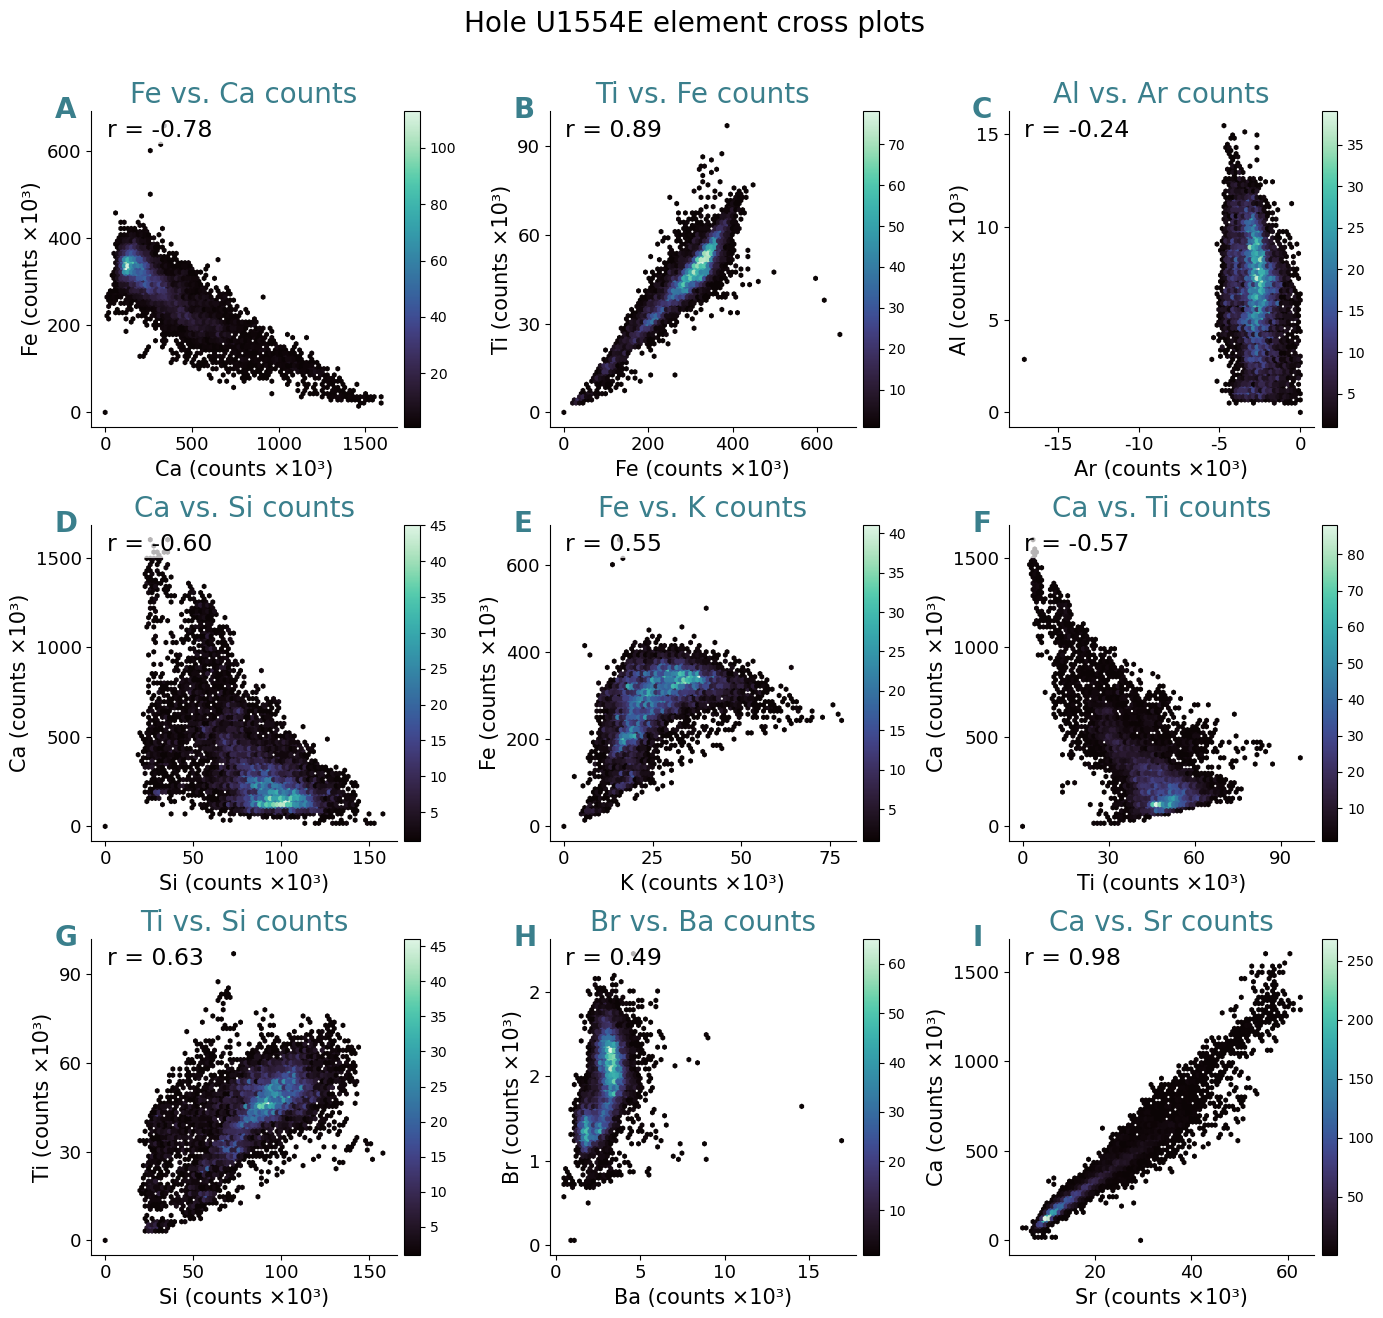

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 13))
axes = axes.flatten()
for ax, (xvar, yvar) in zip(axes, pairs):
    x = get_element(xvar)
    y = get_element(yvar)
    
    df_pair = pd.DataFrame({xvar: x.values[:min(len(x), len(y))], 
                             yvar: y.values[:min(len(x), len(y))]}).dropna()
    
    x_clean = df_pair[xvar]
    y_clean = df_pair[yvar]
    
    hb = ax.hexbin(x_clean, y_clean, gridsize=80, cmap='mako', mincnt=1)
    fig.colorbar(hb, ax=ax, pad=0.02)
    
    r, p = spearmanr(x_clean, y_clean)
    ax.text(0.05, 0.92, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=17, color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
    
    ax.set_title(f'{yvar} vs. {xvar} counts', fontsize=20, color='#3a7f8c', pad=6)
    
    panel_label = chr(65 + list(axes).index(ax))
    ax.text(-0.12, 1.05, panel_label, transform=ax.transAxes,
            fontsize=20, color='#3a7f8c', fontweight='bold', va='top')
    
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.set_xlabel(f'{xvar} (counts ×10³)', fontsize=12)
    ax.set_ylabel(f'{yvar} (counts ×10³)', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

for ax in axes[:len(pairs)]:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/1000:.0f}'))
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(labelsize=13)

fig.suptitle('Hole U1554E element cross plots', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()